# Text Classification Using RNN (PyTorch)

## Imports

In [4]:
import os
import re
import copy
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from datasets import load_dataset, load_from_disk
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix


In [5]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

## Download IMDB Dataset To Local Folder

In [6]:
dataset_dir = './Dataset'
imdb_disk_path = os.path.join(dataset_dir, 'imdb')
os.makedirs(dataset_dir, exist_ok=True)

if not os.path.exists(imdb_disk_path):
    raw_imdb = load_dataset('imdb', cache_dir=dataset_dir)
    raw_imdb.save_to_disk(imdb_disk_path)

raw_dataset = load_from_disk(imdb_disk_path)
raw_dataset


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/25000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/25000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

## Preprocessing

In [7]:
MAX_VOCAB_SIZE = 20000
MAX_SEQ_LEN = 256

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

counter = Counter()
for item in raw_dataset['train']:
    counter.update(simple_tokenize(item['text']))

vocab = ['<PAD>', '<UNK>'] + [word for word, _ in counter.most_common(MAX_VOCAB_SIZE - 2)]
word2idx = {word: idx for idx, word in enumerate(vocab)}
PAD_IDX = word2idx['<PAD>']
UNK_IDX = word2idx['<UNK>']

def encode(text, max_len=MAX_SEQ_LEN):
    tokens = simple_tokenize(text)
    indices = [word2idx.get(t, UNK_IDX) for t in tokens]
    indices = indices[:max_len]
    indices += [PAD_IDX] * (max_len - len(indices))
    return indices


## Dataset And DataLoaders

In [8]:
class IMDBDataset(Dataset):
    def __init__(self, hf_split):
        self.texts = [item['text'] for item in hf_split]
        self.labels = [item['label'] for item in hf_split]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = torch.tensor(encode(self.texts[idx]), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

full_train_dataset = IMDBDataset(raw_dataset['train'])
test_dataset = IMDBDataset(raw_dataset['test'])

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


## RNN Model

In [9]:
class TextRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=1, num_classes=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.rnn(embedded)
        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        out = self.dropout(hidden_cat)
        return self.fc(out)

model = TextRNN(vocab_size=len(vocab)).to(device)
model


TextRNN(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (rnn): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)

## Train And Validation

In [10]:
def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            preds = torch.argmax(logits, dim=1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    return avg_loss, acc, y_true, y_pred

def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3, patience=2):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for _ in range(epochs):
        model.train()
        running_loss = 0.0
        y_true_train = []
        y_pred_train = []

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            preds = torch.argmax(logits, dim=1)
            y_true_train.extend(y.cpu().numpy())
            y_pred_train.extend(preds.cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(y_true_train, y_pred_train)
        val_loss, val_acc, _, _ = evaluate_model(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_weights)
    return model, history

model, history = train_model(model, train_loader, val_loader, epochs=10, lr=1e-3, patience=2)


## Evaluation

In [11]:
criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_true, y_pred = evaluate_model(model, test_loader, criterion)
precision, recall, f1_score, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

metrics_dict = {
    'accuracy': test_acc,
    'precision': precision,
    'recall': recall,
    'f1_score': f1_score
}

pd.DataFrame([metrics_dict])


,accuracy,precision,recall,f1_score
0,0.80712,0.809228,0.80712,0.806791


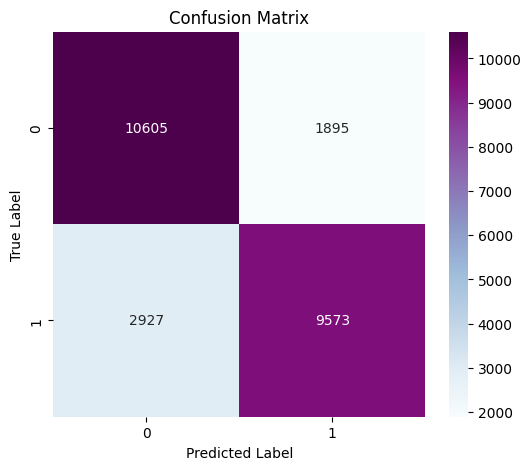

In [12]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, cmap='BuPu', annot=True, fmt='d', xticklabels=[0, 1], yticklabels=[0, 1])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## Save Model

In [13]:
os.makedirs('./Models', exist_ok=True)
model_path = './Models/rnn_imdb_model.pth'
torch.save({'model_state_dict': model.state_dict(), 'vocab_size': len(vocab)}, model_path)
model_path


'./Models/rnn_imdb_model.pth'